# CSoT'26 — ML in Astronomy — Week 1 · Part 1: Foundations (Starter)

**Goal:** Set up Google Colab + a GPU runtime + PyTorch, create a tensor shaped like a galaxy image, and move it onto the GPU.

**Before you begin:**
1. Switch this notebook to a **GPU runtime**: `Runtime → Change runtime type → Hardware accelerator → GPU`.
2. Re-read [`09-project-task.md`](../09-project-task.md) if you haven't already.

Each `TODO` cell has a short instruction. Replace the placeholder with working code, then run the cell. If you get stuck, the concept markdowns in this folder cover everything you need.

**Do not** open `week1_solution.ipynb` until you've genuinely attempted every TODO here. Once you finish Part 1, move on to **Part 2** in `week1_data_starter.ipynb`.

## Step 1 — Confirm the GPU at the OS level

Run the shell command below. You should see a table mentioning an NVIDIA Tesla T4 (or similar). If you see `command not found`, your runtime is on CPU — fix it via `Runtime → Change runtime type → GPU`, then re-run.

In [1]:
!nvidia-smi

Mon Jun  1 15:55:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Imports and version sanity check

Import `torch`, `torchvision`, and `matplotlib.pyplot as plt`. Print their versions. Colab pre-installs all three.

*Hint:* `torch.__version__`, `torchvision.__version__`, `matplotlib.__version__`.

In [3]:
# TODO: import torch, torchvision, matplotlib.pyplot as plt
#       then print each library's __version__.
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)
print(matplotlib.__version__)

2.11.0+cu128
0.26.0+cu128
3.10.0


## Step 3 — Confirm the GPU from PyTorch

Print:
1. `torch.cuda.is_available()` — should be `True`.
2. `torch.cuda.device_count()` — should be at least `1`.
3. `torch.cuda.get_device_name(0)` — should be a real GPU name.

*Hint:* wrap (3) in an `if torch.cuda.is_available()` so it doesn't crash if you're (accidentally) on CPU.

In [4]:
# TODO: print the three things above.
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla T4


## Step 4 — Define the `device` variable

The classic portable idiom: `device = "cuda" if torch.cuda.is_available() else "cpu"`. Print it.

In [5]:
# TODO: define `device` and print it.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## Step 5 — Create a 'toy galaxy' tensor on the CPU

Make a random tensor `x` of shape `(3, 64, 64)` using `torch.randn`. This is the same shape one galaxy image will have once we resize it next week (3 channels × 64 × 64 pixels).

Print `x.shape`, `x.dtype`, and `x.device`. You should see `cpu` for the device.

In [6]:
# TODO: create x and print its three attributes.
x = torch.randn(3, 64, 64)
print(x.shape)
print(x.dtype)
print(x.device)

torch.Size([3, 64, 64])
torch.float32
cpu


## Step 6 — Move the tensor to the GPU

Use `.to(device)`. Save the result as `x_gpu`. Print `x_gpu.device`. You should see `cuda:0` (assuming the GPU is alive).

Then verify the shape is unchanged: `x_gpu.shape` should still be `torch.Size([3, 64, 64])`.

In [7]:
# TODO: x_gpu = x.to(device)
#       print x_gpu.device and x_gpu.shape.
x_gpu = x.to(device)
print(x_gpu.device)
print(x_gpu.shape)

cuda:0
torch.Size([3, 64, 64])


## Step 7 — Do something on the GPU

Take the first channel of `x_gpu` (`x_gpu[0]` → shape `(64, 64)`), matrix-multiply it with itself using `@`, and print the resulting tensor's shape and device. The shape should still be `(64, 64)` and the device should still be `cuda:0`.

In [8]:
# TODO: result = x_gpu[0] @ x_gpu[0]
#       print result.shape and result.device.
result = x_gpu[0] @ x_gpu[0]
print(result.shape)
print(result.device)


torch.Size([64, 64])
cuda:0


## Stretch Goal 1 — CPU vs GPU benchmark *(optional)*

Adapt the snippet from [`03-gpu-acceleration.md`](../03-gpu-acceleration.md) to time a matmul of two `(4096, 4096)` matrices on CPU vs GPU. Report the speedup. Don't forget `torch.cuda.synchronize()` before timing the GPU.

In [10]:
# TODO (optional): benchmark and print CPU time, GPU time, and the speedup ratio.
import time
import torch

size = 4096
n_runs = 5

def bench(device):
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)
    # warm-up (especially important for GPU)
    for _ in range(2):
        (a @ b).sum().item()
    if device == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    for _ in range(n_runs):
        c = a @ b
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    return (t1 - t0) / n_runs


cpu_t = bench('cpu')
print(f"CPU avg : {cpu_t*1000:.1f} ms")
if torch.cuda.is_available():
    gpu_t = bench('cuda')
    print(f"GPU avg : {gpu_t*1000:.1f} ms")

print(f"speedup ratio is {cpu_t/gpu_t} .")


CPU avg : 1326.3 ms
GPU avg : 41.8 ms
speedup ratio is 31.699712392736217 .


## Stretch Goal 2 — Visualise a 'synthetic galaxy' *(optional)*

Use the cartoon construction from [`09-project-task.md`](../09-project-task.md) (Stretch Goal 3) to build a `(128, 128)` brightness map of a fake galaxy and display it with `plt.imshow`. Use a colormap like `inferno` or `magma`. Hide the axes for aesthetics.

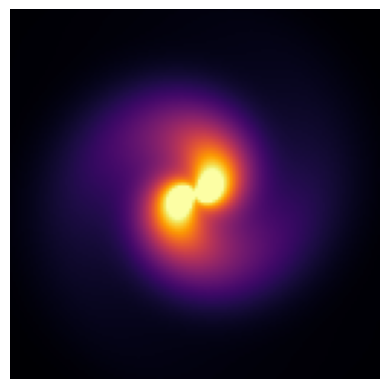

In [11]:
# TODO (optional): build and display a synthetic galaxy.
import torch, math
import matplotlib.pyplot as plt

H, W = 128, 128
y, x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing="ij")
r = torch.sqrt(x**2 + y**2)
theta = torch.atan2(y, x)

# An exponentially declining brightness profile (very loosely Sersic n=1)
disk = torch.exp(-r * 4)

# Add a faint two-arm spiral pattern
arms = 0.5 * torch.exp(-r * 4) * (1 + torch.cos(2 * theta + 8 * r))

galaxy = (disk + arms).clamp(0, 1).numpy()
plt.imshow(galaxy, cmap="inferno")
plt.axis("off")
plt.show()

## Reflection *(write 2–3 sentences in this cell)*

Before you submit, answer the three reflection prompts from [`09-project-task.md`](../09-project-task.md) right here:

1. What was the most confusing part of getting Colab + GPU + PyTorch set up? How did you resolve it?
2. Pick one galaxy class (E / S / S0 / Irr) and describe what features a CNN might need to recognise it.
3. Why do you think we'll spend an entire week on data pipelines next, before any model training?

*(Replace this italic prompt with your answers.)*


My Reflections:

1. I have already worked on Google Colab before, so setting up wasn't a problem, but it was my first time PyTorch module. I had to read some tutorial articles and understand various data types like difference between rand and randn.

2. For S type galaxy, CNN might recognise it by central bulge, disk shape and spiral arms.

3. If the data is not properly cleaned, labeled, and organized, a CNN cannot learn meaningful features.